Apply a log transformation to the image 
In the same figure area 
Apply a gamma transform with a gamma value of your own choosing somewhere between 0.1 and 0.5
Apply a second gamma transform with a gamma value of your own choosing somewhere between 2.0 and 4.0
In the same figure are display the original image and  both gamma transformed results side by side 

Apply a piecewise linear transformation to the image using control points of your own choosing 
Apply a second piecewise linear transformation to the image using different set of control points 
In  the same figure area display the original image and both piecewise transformed results side by side 

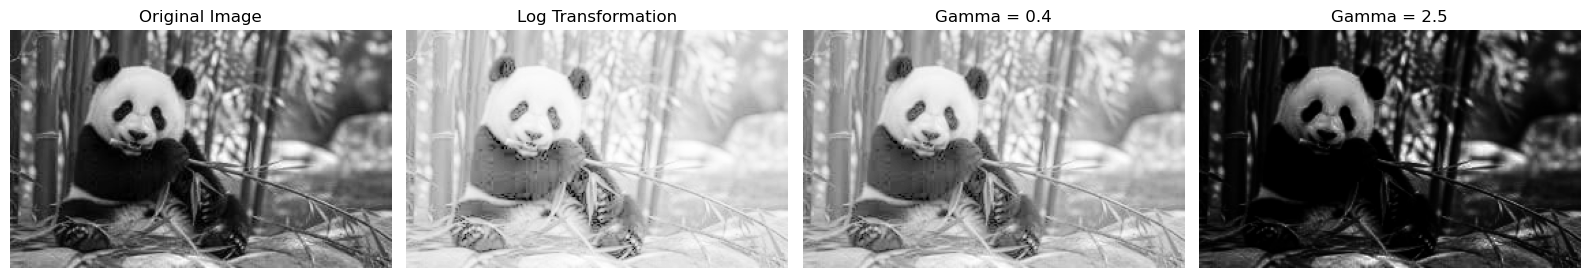

In [4]:
# ==========================================
# LOG AND GAMMA TRANSFORMATIONS
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Load image
img = np.array(Image.open("image2.jpg").convert("L"))

# Convert image to float
img_float = img.astype(np.float32)

# Normalize image to 0-1
normalized = img_float / 255.0

# -------------------------
# Log Transformation
# -------------------------
c = 255 / np.log(1 + np.max(img_float))

log_transformed = c * np.log(1 + img_float)
log_transformed = np.clip(log_transformed, 0, 255)
log_transformed = log_transformed.astype(np.uint8)

# -------------------------
# Gamma = 0.4
# -------------------------
gamma_04 = cv2.pow(normalized, 0.4) * 255.0
gamma_04 = np.clip(gamma_04, 0, 255)
gamma_04 = gamma_04.astype(np.uint8)

# -------------------------
# Gamma = 2.5
# -------------------------
gamma_25 = cv2.pow(normalized, 2.5) * 255.0
gamma_25 = np.clip(gamma_25, 0, 255)
gamma_25 = gamma_25.astype(np.uint8)

# -------------------------
# Display
# -------------------------
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(log_transformed, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(gamma_04, cmap="gray")
plt.title("Gamma = 0.4")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(gamma_25, cmap="gray")
plt.title("Gamma = 2.5")
plt.axis("off")

plt.tight_layout()
plt.show()

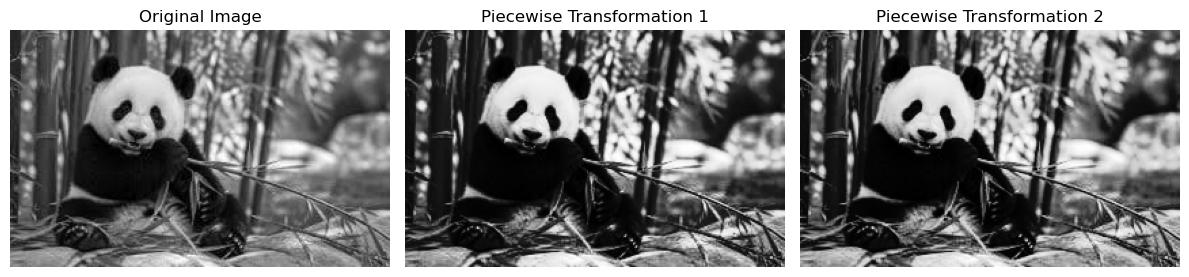

In [5]:
# ==========================================
# PIECEWISE LINEAR TRANSFORMATIONS
# ==========================================

# Function for piecewise linear transformation
def piecewise_linear(image, r1, s1, r2, s2):

    result = np.zeros_like(image, dtype=np.float32)

    # Region 1
    mask1 = image <= r1
    result[mask1] = (s1 / r1) * image[mask1]

    # Region 2
    mask2 = (image > r1) & (image <= r2)
    result[mask2] = ((s2 - s1) / (r2 - r1)) * (image[mask2] - r1) + s1

    # Region 3
    mask3 = image > r2
    result[mask3] = ((255 - s2) / (255 - r2)) * (image[mask3] - r2) + s2

    return np.clip(result, 0, 255).astype(np.uint8)


# ------------------------------------------
# Piecewise Transformation 1
# Control points:
# (0,0), (80,30), (180,220), (255,255)
# ------------------------------------------

piecewise_1 = piecewise_linear(
    img,
    80, 30,
    180, 220
)


# ------------------------------------------
# Piecewise Transformation 2
# Control points:
# (0,0), (60,20), (160,200), (255,255)
# ------------------------------------------

piecewise_2 = piecewise_linear(
    img,
    60, 20,
    160, 200
)


# ------------------------------------------
# Display results
# ------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(piecewise_1, cmap="gray")
plt.title("Piecewise Transformation 1")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(piecewise_2, cmap="gray")
plt.title("Piecewise Transformation 2")
plt.axis("off")

plt.tight_layout()
plt.show()

